# Demo 2 — Spontaneous activity (2-D sheet)

The same idea as Demo 1 but on a 2-D cortical sheet: band-pass noisy input drives
near-critical networks and we look at the emergent spontaneous activity maps for
several connectivity profiles.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in the repository folder (itself named
# "cortical_rate_model"), so we add its PARENT directory to the path.
# Walking up from the working directory lets this notebook run from the
# demos/ folder, from the repository root, or from anywhere inside the repo.
import sys, pathlib
_cwd = pathlib.Path.cwd()
for _p in (_cwd, *_cwd.parents):
    if _p.name == "cortical_rate_model" and (_p / "network.py").exists():
        sys.path.insert(0, str(_p.parent))
        break
else:
    raise RuntimeError("Could not locate the cortical_rate_model package directory.")


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

In [3]:
sheet = Layout((24, 24), periodic=True)
spont_drive = inputs.noisy_background(sheet, noise_level=0.5, baseline=1.0,
                                      n_patterns=4, sigma1=1.0, seed=2)
print("spontaneous drive shape:", spont_drive.shape)

profiles = {
    "mexican_hat":           dict(sigma=1.8, inh_factor=2.5),
    "grf_mexican_hat":       dict(sigma=1.8, inh_factor=2.0, grf_strength=0.5),
    "elongated_mexican_hat": dict(sigma=1.8, inh_factor=2.5, eccentricity=0.8),
    "modular":               dict(dist_spec=5.0),
}

spontaneous drive shape: (4, 576)


## Spontaneous maps per profile

Rows = connectivity profile, columns = independent noise realisations. Mexican-hat
sheets produce periodic blob patterns; the elongated profile gives oriented,
iso-orientation-domain-like structure; the modular profile gives distributed
patches.

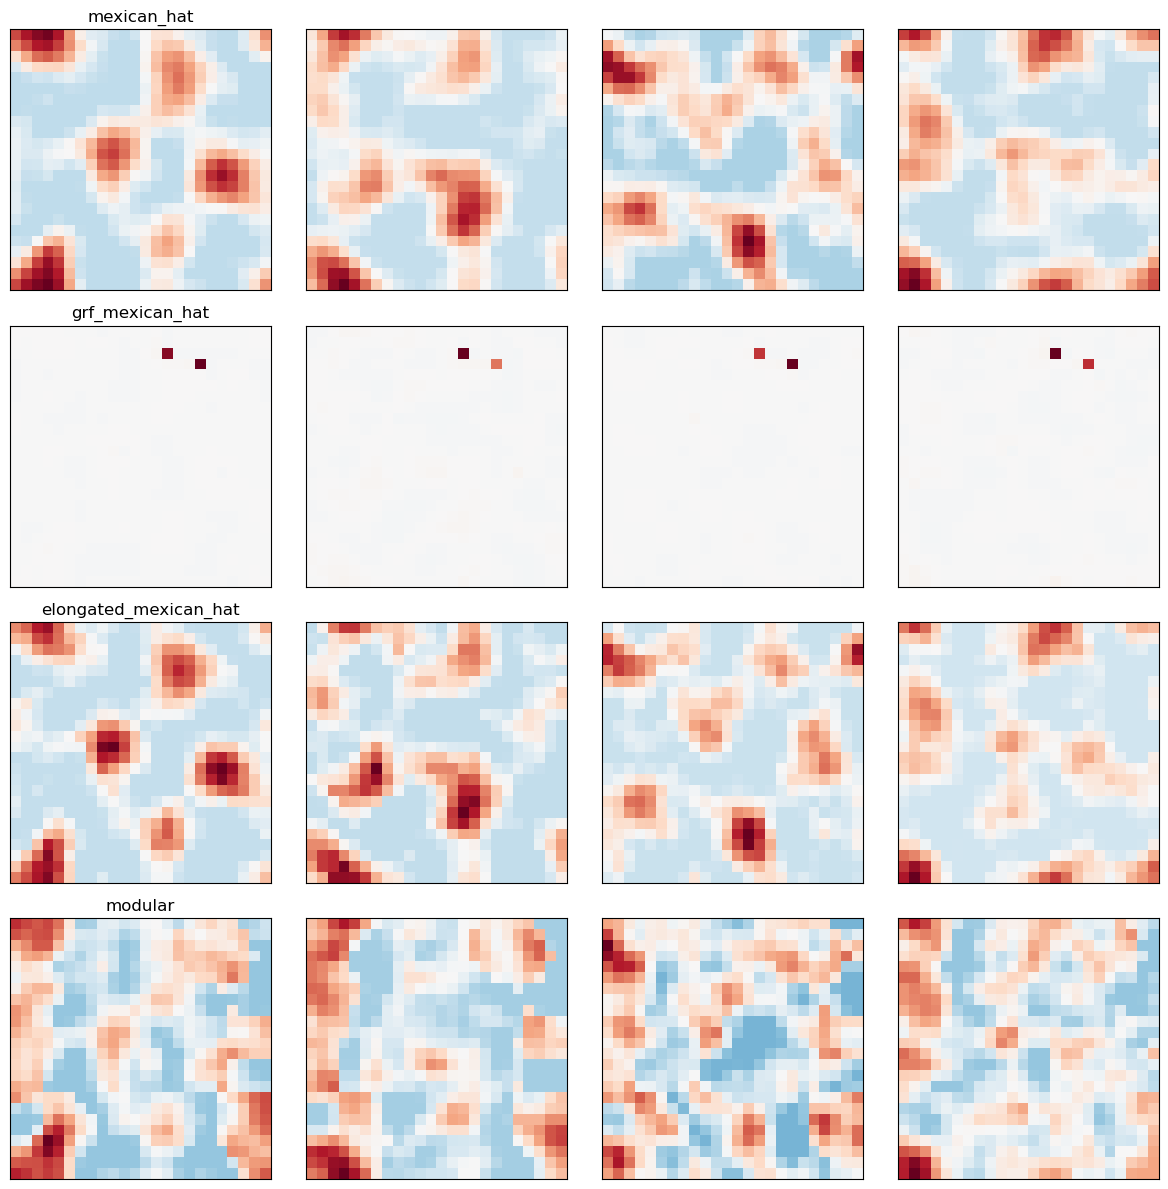

In [4]:
n_show = spont_drive.shape[0]
fig, axes = plt.subplots(len(profiles), n_show, figsize=(3 * n_show, 3 * len(profiles)))
for row, (kind, params) in enumerate(profiles.items()):
    net = build_net(kind, sheet, **params)
    resp = net.response(spont_drive, n_steps=300)
    resp = resp - resp.mean(axis=1, keepdims=True)
    for col in range(n_show):
        ax = axes[row, col]
        plotting.plot_pattern(resp[col], sheet, ax=ax, colorbar=False,
                              title=(kind if col == 0 else ""))
plt.tight_layout(); plt.show()

## E/I sheet

Excitatory spontaneous activity of a two-population sheet.

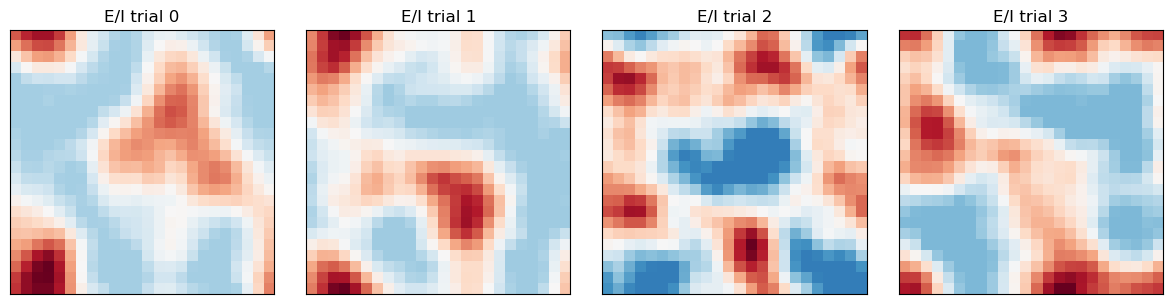

In [5]:
ei = build_ei(sheet, sigma_ee=2.0, sigma_ei=5.0, sigma_ie=2.0, sigma_ii=5.0)
drive_ei = inputs.to_ei_input(exc_input=spont_drive, num_units=sheet.num_units)
r = ei.response(drive_ei, n_steps=400)
r_exc, _ = ei.split_activity(r)
r_exc = r_exc - r_exc.mean(axis=1, keepdims=True)

fig, axes = plt.subplots(1, r_exc.shape[0], figsize=(3 * r_exc.shape[0], 3))
for col, ax in enumerate(axes):
    plotting.plot_pattern(r_exc[col], sheet, ax=ax, colorbar=False,
                          title=f"E/I trial {col}")
plt.tight_layout(); plt.show()